# AI Use Declaration

We declare that we used the following AI tools for the following purposes, but no AI was used in directly
solving the problem by entering the problem statement or any part thereof into any AI tool.

Github Copilot for obtaining the CPV for KPCA, some bit of formatting, and debugging syntax errors.

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from sklearn.pipeline import make_pipeline
import seaborn as sns
from sklearn.decomposition import PCA, KernelPCA
from sklearn import manifold
from sklearn.datasets import load_digits

X, y = load_digits(return_X_y=True)
print(X.shape, y.shape)

(1797, 64) (1797,)


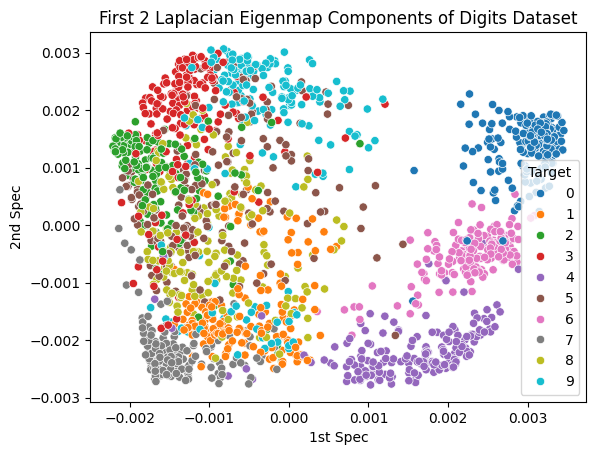

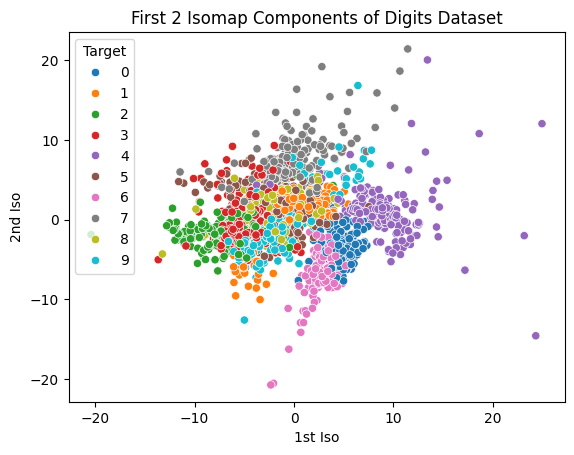

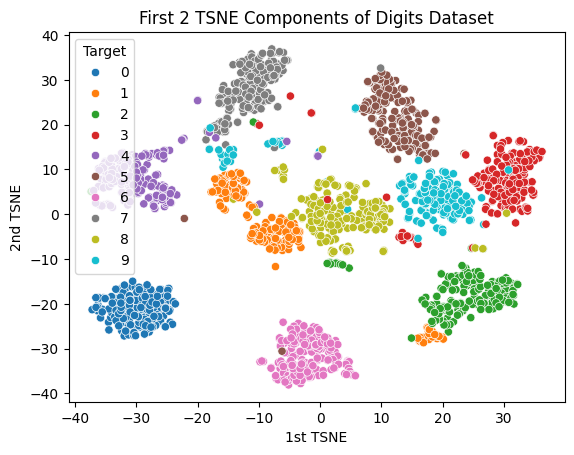

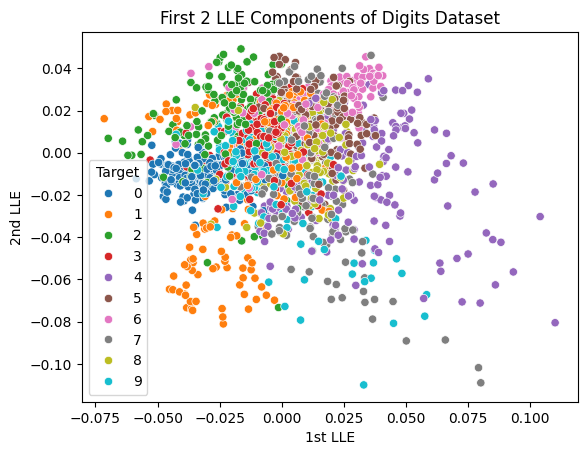

In [25]:
spec = make_pipeline(StandardScaler(), manifold.SpectralEmbedding(n_neighbors=200, random_state=0))
X_spec = spec.fit_transform(X)

iso = make_pipeline(StandardScaler(), manifold.Isomap(n_neighbors=200))
X_iso = iso.fit_transform(X)

tsne = make_pipeline(StandardScaler(), manifold.TSNE(perplexity = 50, random_state = 0))
X_tsne = tsne.fit_transform(X)

lle = make_pipeline(StandardScaler(), manifold.LocallyLinearEmbedding(n_neighbors = 200, random_state = 0))
X_lle = lle.fit_transform(X)

df_spec = pd.DataFrame(data=X_spec[:, :2], columns=['1st Spec','2nd Spec'])
df_spec['Target'] = y
sns.scatterplot(data=df_spec, x="1st Spec", y="2nd Spec", hue="Target", palette='tab10')
plt.title('First 2 Laplacian Eigenmap Components of Digits Dataset')
plt.show()

df_iso = pd.DataFrame(data=X_iso[:, :2], columns=['1st Iso','2nd Iso'])
df_iso['Target'] = y
sns.scatterplot(data=df_iso, x="1st Iso", y="2nd Iso", hue="Target", palette='tab10')
plt.title('First 2 Isomap Components of Digits Dataset')
plt.show()

df_tsne = pd.DataFrame(data=X_tsne[:, :2], columns=['1st TSNE','2nd TSNE'])
df_tsne['Target'] = y
sns.scatterplot(data=df_tsne, x="1st TSNE", y="2nd TSNE", hue="Target", palette='tab10')
plt.title('First 2 TSNE Components of Digits Dataset')
plt.show()

df_lle = pd.DataFrame(data=X_lle[:, :2], columns=['1st LLE','2nd LLE'])
df_lle['Target'] = y
sns.scatterplot(data=df_lle, x="1st LLE", y="2nd LLE", hue="Target", palette='tab10')
plt.title('First 2 LLE Components of Digits Dataset')
plt.show()



A. Which methods produced clear clusters?

Of all the methods, t-SNE produced the cleanest clusters. Isomap had good separation but only over a small area. The Laplacian Eigenmap and KPCA was able to separate digits 0, 4, and 6 quite well but struggled with the others. PCA did okay, but LLE struggled the most.

Components for ≥95% CPV: 40


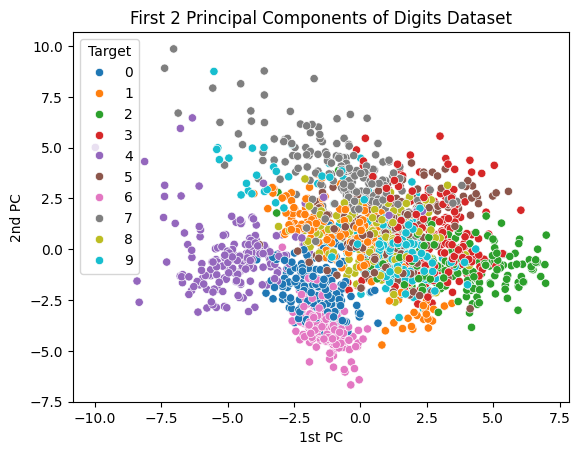

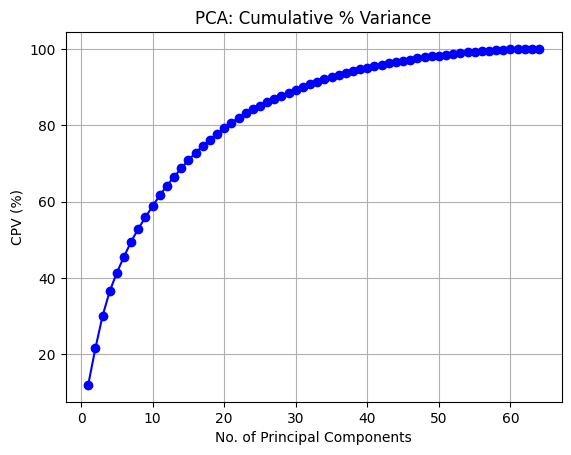

In [26]:
pca = make_pipeline(StandardScaler(), PCA())
X_pca = pca.fit(X).transform(X)
var = pca[1].explained_variance_ratio_
cpv = np.cumsum(var)*100
k95 = int(np.searchsorted(cpv, 95) + 1)
print(f'Components for ≥95% CPV: {k95}')

df = pd.DataFrame(data=X_pca[:, :2], columns=['1st PC','2nd PC'])
df['Target'] = y
sns.scatterplot(data=df, x="1st PC", y="2nd PC", hue="Target", palette='tab10')
plt.title('First 2 Principal Components of Digits Dataset')
plt.show()

plt.plot(np.arange(cpv.size)+1,cpv,'bo-')
plt.title('PCA: Cumulative % Variance')
plt.xlabel('No. of Principal Components')
plt.ylabel('CPV (%)')
plt.grid()
plt.show()


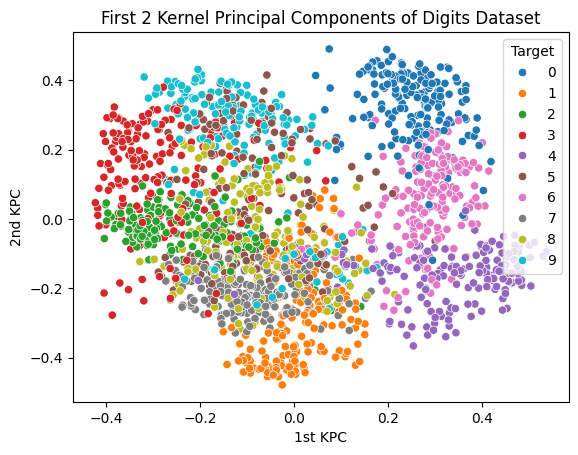

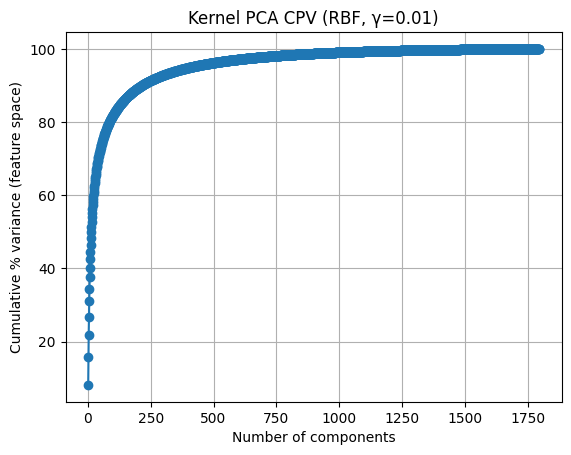

Components for ≥95% CPV: 408


In [27]:
kpca = make_pipeline(StandardScaler(), KernelPCA(kernel='rbf', gamma=0.01))
X_kpca = kpca.fit(X).transform(X)
df_kpca = pd.DataFrame(data=X_kpca[:, :2], columns=['1st KPC','2nd KPC'])

df_kpca['Target'] = y
sns.scatterplot(data=df_kpca, x="1st KPC", y="2nd KPC", hue="Target", palette='tab10')
plt.title('First 2 Kernel Principal Components of Digits Dataset')
plt.show()

scaler = kpca.named_steps['standardscaler']
X_scaled = scaler.transform(X)
kpca_full = KernelPCA(kernel='rbf', gamma=0.01)
kpca_full.fit(X_scaled)

# USED COPILOT HERE #
lmbda = getattr(kpca_full, 'lambdas_', getattr(kpca_full, 'eigenvalues_', None))
lmbda = np.clip(lmbda, 0, None)        # guard against tiny negative round-off
evr = lmbda / lmbda.sum()
cpv = np.cumsum(evr) * 100

plt.figure()
plt.plot(np.arange(1, len(cpv)+1), cpv, marker='o')
plt.xlabel('Number of components')
plt.ylabel('Cumulative % variance (feature space)')
plt.title('Kernel PCA CPV (RBF, γ=0.01)')
plt.grid(True)
plt.show()

k95 = int(np.searchsorted(cpv, 95) + 1)
print(f'Components for ≥95% CPV: {k95}')

B. Report the CPV plot and determine the number of PCs for >= 95% CPV

To retain 95% CPV for PCA, we need 40 components. For Kernel PCA with RBF kernel (gamma=0.01), we need 406 components to reach >= 95% CPV. The CPV plots for both PCA and KPCA are shown above.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=5, stratify=y)

kpca = make_pipeline(StandardScaler(), KernelPCA(kernel = 'sigmoid', n_components=40), SVC())
kpca.fit(X_train, y_train)
y_pred_kpca = kpca.predict(X_test)
print(classification_report(y_test, y_pred_kpca))

print(f"Training Accuracy: {kpca.score(X_train,y_train)}")
print(f"Testing Accuracy: {kpca.score(X_test,y_test)}")

print('Training: Confusion Matrix')
print(confusion_matrix(y_train, kpca.predict(X_train)))
print('Testing: Confusion Matrix')
print(confusion_matrix(y_test, kpca.predict(X_test)))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       0.98      1.00      0.99        55
           2       1.00      1.00      1.00        53
           3       1.00      0.98      0.99        55
           4       1.00      1.00      1.00        54
           5       1.00      0.96      0.98        55
           6       0.98      0.98      0.98        54
           7       1.00      0.98      0.99        54
           8       0.98      1.00      0.99        52
           9       0.96      1.00      0.98        54

    accuracy                           0.99       540
   macro avg       0.99      0.99      0.99       540
weighted avg       0.99      0.99      0.99       540

Training Accuracy: 0.9984089101034208
Testing Accuracy: 0.9907407407407407
Training: Confusion Matrix
[[124   0   0   0   0   0   0   0   0   0]
 [  0 127   0   0   0   0   0   0   0   0]
 [  0   0 124   0   0   0   0   0   0   0]
 [  0   0 

The accuracy and F1-score on the test set using Kernel PCA and SVC were at 99.1% on the test set.

In [29]:
lda = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis(n_components=9), SVC())
lda.fit(X_train, y_train)
y_pred_lda = lda.predict(X_test)
print(classification_report(y_test, y_pred_lda))

print(f"Training Accuracy: {lda.score(X_train,y_train)}")
print(f"Testing Accuracy: {lda.score(X_test,y_test)}")

print('Training: Confusion Matrix')
print(confusion_matrix(y_train, lda.predict(X_train)))
print('Testing: Confusion Matrix')
print(confusion_matrix(y_test, lda.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       0.92      0.98      0.95        55
           2       0.96      0.98      0.97        53
           3       0.98      0.89      0.93        55
           4       1.00      0.98      0.99        54
           5       1.00      0.95      0.97        55
           6       0.98      0.96      0.97        54
           7       0.98      0.98      0.98        54
           8       0.89      0.90      0.90        52
           9       0.90      0.96      0.93        54

    accuracy                           0.96       540
   macro avg       0.96      0.96      0.96       540
weighted avg       0.96      0.96      0.96       540

Training Accuracy: 0.9880668257756563
Testing Accuracy: 0.9592592592592593
Training: Confusion Matrix
[[123   0   0   0   0   0   1   0   0   0]
 [  0 127   0   0   0   0   0   0   0   0]
 [  0   0 124   0   0   0   0   0   0   0]
 [  0   0 

LDA and SVC yielded 95.9% accuracy and F1-score for the test set. The number of components for LDA is only limited to p-1 components, where p is the number of classes. Since we have 10 classes from 0 to 9, we can only have 9 components.

In [30]:
svm = make_pipeline(StandardScaler(), SVC())
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print(classification_report(y_test, y_pred_svm))

print(f"Training Accuracy: {svm.score(X_train,y_train)}")
print(f"Testing Accuracy: {svm.score(X_test,y_test)}")

print('Training: Confusion Matrix')
print(confusion_matrix(y_train, svm.predict(X_train)))
print('Testing: Confusion Matrix')
print(confusion_matrix(y_test, svm.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       0.98      1.00      0.99        55
           2       1.00      1.00      1.00        53
           3       1.00      0.95      0.97        55
           4       0.98      0.98      0.98        54
           5       1.00      0.95      0.97        55
           6       0.98      0.98      0.98        54
           7       0.98      0.96      0.97        54
           8       0.95      1.00      0.97        52
           9       0.93      0.98      0.95        54

    accuracy                           0.98       540
   macro avg       0.98      0.98      0.98       540
weighted avg       0.98      0.98      0.98       540

Training Accuracy: 0.9984089101034208
Testing Accuracy: 0.9796296296296296
Training: Confusion Matrix
[[124   0   0   0   0   0   0   0   0   0]
 [  0 127   0   0   0   0   0   0   0   0]
 [  0   0 124   0   0   0   0   0   0   0]
 [  0   0 

In [31]:
print('Acc (KPCA+SVC):', accuracy_score(y_test, y_pred_kpca))
print('Weighted F1 (KPCA+SVC):', f1_score(y_test, y_pred_kpca, average='weighted'))

print('Acc (LDA+SVC):', accuracy_score(y_test, y_pred_lda))
print('Weighted F1 (LDA+SVC):', f1_score(y_test, y_pred_lda, average='weighted'))

print('Acc (SVC):', accuracy_score(y_test, y_pred_svm))
print('Weighted F1 (SVC):', f1_score(y_test, y_pred_svm, average='weighted'))

Acc (KPCA+SVC): 0.9907407407407407
Weighted F1 (KPCA+SVC): 0.990740128992167
Acc (LDA+SVC): 0.9592592592592593
Weighted F1 (LDA+SVC): 0.9594205659527844
Acc (SVC): 0.9796296296296296
Weighted F1 (SVC): 0.9796592542698462


Lastly, the accuracy and F1-score of SVC without dimensionality reduction is 98.0%. This is higher than LDA + SVC, but lower than KPCA + SVC.

Of the three methods, KPCA + SVC produced the highest accuracy and weighted F1. LDA + SVC underperforms mainly because LDA is a linear projection and is capped at 9 dimensions for 10 classes, which can’t capture the digits’ nonlinear structure. It is difficult for SVC-only on the original 64 components to identify decision boundaries due to its high feature space. KPCA provides a nonlinear feature map that unwraps digit manifolds and removes less important components. The SVC then has an easier time to find decision boundaries compared to just using SVC without using KPCA. 